In [1]:
from ultralytics import YOLO
from pathlib import Path
from PIL import Image
from IPython.display import display

In [2]:
PROJECT_DIR = Path.cwd().parent

MODEL_PATH = PROJECT_DIR / "models" / "foodlens_yolo11n_best.pt"

model = YOLO(str(MODEL_PATH))

print("Model loaded successfully!")

Model loaded successfully!


In [9]:
def detect_food(image_path, confidence=0.005):

    results = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=confidence,
        device=0,
        verbose=False
    )

    detections = []

    for result in results:

        if result.boxes is None or len(result.boxes) == 0:
            continue

        for box in result.boxes:

            class_id = int(box.cls[0])
            conf = float(box.conf[0])

            x1, y1, x2, y2 = box.xyxy[0].tolist()

            food_name = model.names[class_id]

            detections.append({
                "food": food_name,
                "confidence": conf,
                "box": [x1, y1, x2, y2]
            })

    return detections

In [10]:
IMAGE_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "foodlens_20"
    / "test"
    / "images"
)

image_path = list(IMAGE_DIR.glob("*.jpg"))[0]

detections = detect_food(image_path)

detections

[{'food': 'dal makhani',
  'confidence': 0.5669745802879333,
  'box': [292.06719970703125,
   314.3669738769531,
   731.4306640625,
   761.68408203125]},
 {'food': 'chapati',
  'confidence': 0.05248898267745972,
  'box': [0.0, 361.7559509277344, 281.5939636230469, 756.5726928710938]},
 {'food': 'chapati',
  'confidence': 0.00788745004683733,
  'box': [147.200439453125,
   132.7940216064453,
   579.6336669921875,
   520.8512573242188]},
 {'food': 'chapati',
  'confidence': 0.007143884897232056,
  'box': [55.0374755859375,
   376.03912353515625,
   306.6276550292969,
   751.1505126953125]},
 {'food': 'chapati',
  'confidence': 0.006253514904528856,
  'box': [169.7775421142578,
   440.61614990234375,
   341.18536376953125,
   686.8680419921875]}]

In [11]:
from collections import Counter

food_counts = Counter(
    detection["food"]
    for detection in detections
)

print("========== FOOD COUNT ==========")

for food, count in food_counts.items():
    print(f"{food}: {count}")

========== FOOD COUNT ==========
dal makhani: 1
chapati: 4


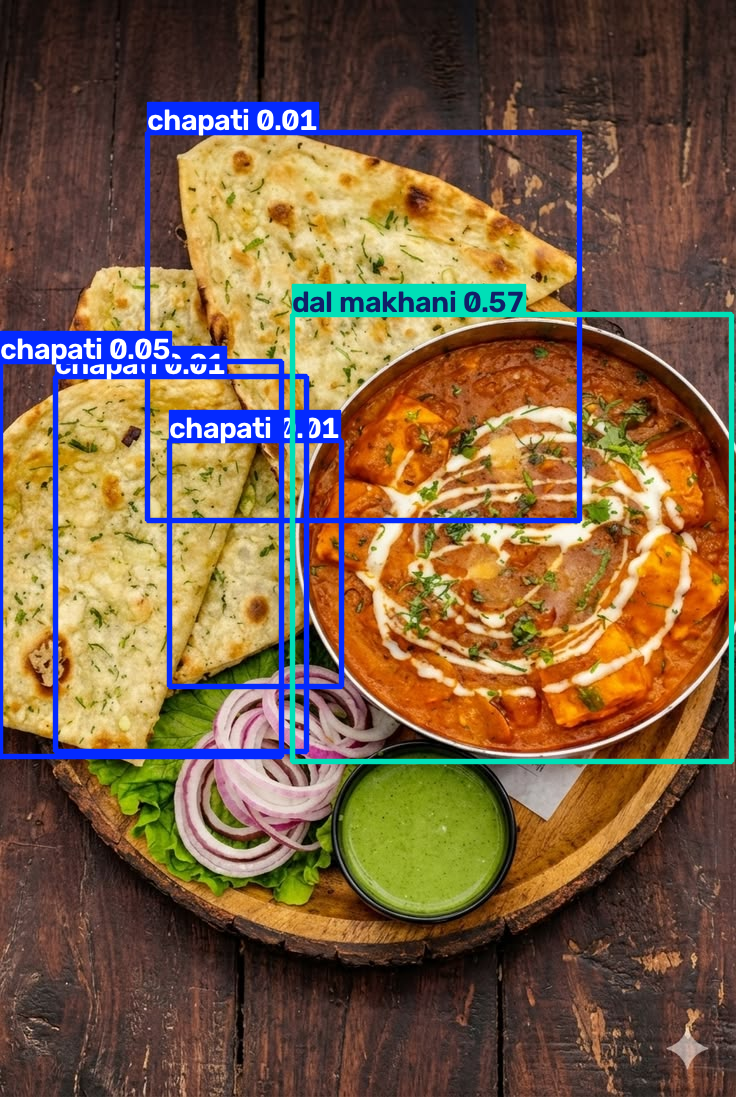

In [12]:
results = model.predict(
    source=str(image_path),
    imgsz=640,
    conf=0.005,
    device=0,
    verbose=False
)

result_image = results[0].plot()

display(Image.fromarray(result_image[..., ::-1]))

In [13]:
print("========== MODEL CHECK ==========")

print("Model path:")
print(MODEL_PATH)

print("\nModel exists:")
print(MODEL_PATH.exists())

print("\nNumber of classes:")
print(len(model.names))

print("\nClasses:")
print(model.names)

========== MODEL CHECK ==========
Model path:
d:\FoodLens_AI\models\foodlens_yolo11n_best.pt

Model exists:
True

Number of classes:
20

Classes:
{0: 'chapati', 1: 'naan', 2: 'daal', 3: 'dal makhani', 4: 'dal tadka', 5: 'chana masala', 6: 'aloo gobi', 7: 'aloo matar', 8: 'bhindi masala', 9: 'kadai paneer', 10: 'palak paneer', 11: 'paneer butter masala', 12: 'biryani', 13: 'poha', 14: 'lassi', 15: 'bhatura', 16: 'aloo tikki', 17: 'kachori', 18: 'gulab jamun', 19: 'jalebi'}


========== IMAGE CHECK ==========
Image path:
d:\FoodLens_AI\data\processed\foodlens_20\test\images\000000_jpg.rf.jpg

Image exists:
True

Image size:
(736, 1097)


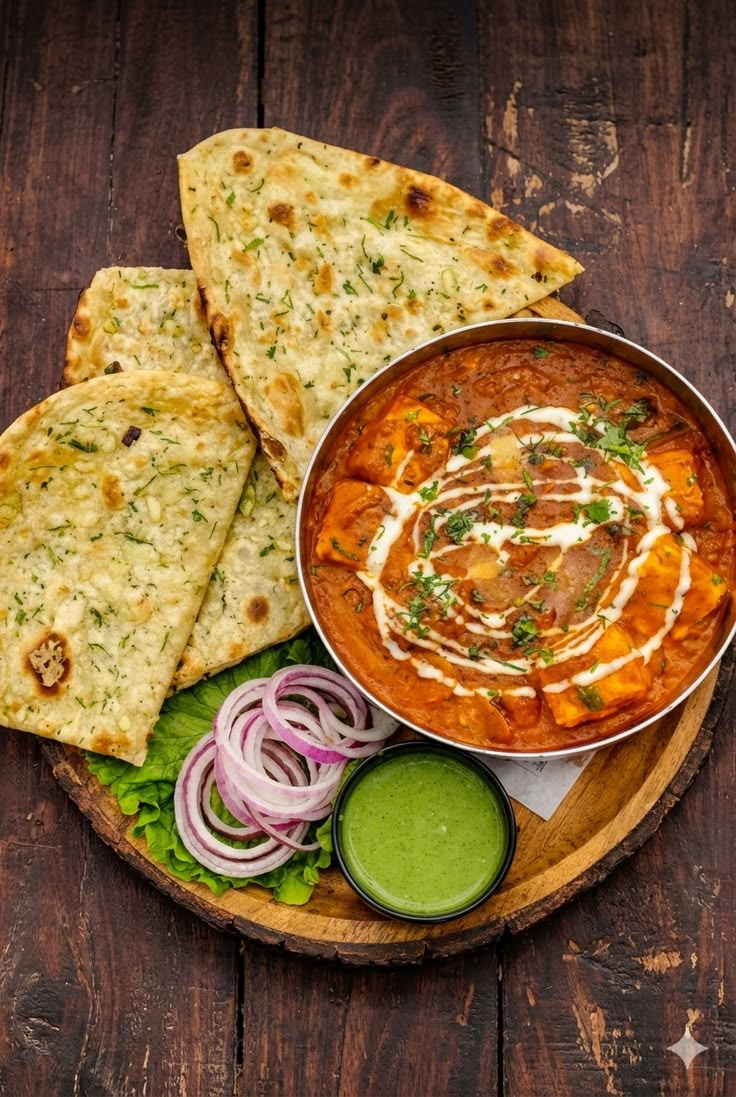

In [14]:
print("========== IMAGE CHECK ==========")

print("Image path:")
print(image_path)

print("\nImage exists:")
print(image_path.exists())

image = Image.open(image_path)

print("\nImage size:")
print(image.size)

display(image)

In [16]:
raw_results = model.predict(
    source=str(image_path),
    imgsz=640,
    conf=0.005,
    device=0,
    verbose=False
)

for result in raw_results:

    print("Number of detections:", len(result.boxes))

    for box in result.boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        food_name = model.names[class_id]

        print(
            f"{food_name:25s} "
            f"confidence = {confidence:.6f}"
        )

Number of detections: 5
dal makhani               confidence = 0.566975
chapati                   confidence = 0.052489
chapati                   confidence = 0.007887
chapati                   confidence = 0.007144
chapati                   confidence = 0.006254


In [17]:
confidence_levels = [0.25, 0.10, 0.005]

for conf in confidence_levels:

    print("\n" + "=" * 50)
    print(f"CONFIDENCE THRESHOLD = {conf}")
    print("=" * 50)

    results = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=conf,
        device=0,
        verbose=False
    )

    for result in results:

        if len(result.boxes) == 0:
            print("No detections")
            continue

        for box in result.boxes:

            class_id = int(box.cls[0])
            confidence = float(box.conf[0])

            food_name = model.names[class_id]

            print(
                f"{food_name:25s} | "
                f"{confidence:.2%}"
            )


CONFIDENCE THRESHOLD = 0.25
dal makhani               | 56.70%

CONFIDENCE THRESHOLD = 0.1
dal makhani               | 56.70%

CONFIDENCE THRESHOLD = 0.005
dal makhani               | 56.70%
chapati                   | 5.25%
chapati                   | 0.79%
chapati                   | 0.71%
chapati                   | 0.63%


In [18]:
# Find the label file for our current image

label_path = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "foodlens_20"
    / "test"
    / "labels"
    / f"{image_path.stem}.txt"
)

print("Image:")
print(image_path.name)

print("\nLabel file:")
print(label_path)

print("\nLabel exists:")
print(label_path.exists())


Image:
000000_jpg.rf.jpg

Label file:
d:\FoodLens_AI\data\processed\foodlens_20\test\labels\000000_jpg.rf.txt

Label exists:
False


In [19]:
IMAGE_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "foodlens_20"
    / "test"
    / "images"
)

LABEL_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "foodlens_20"
    / "test"
    / "labels"
)

multi_food_images = []

for image_path in IMAGE_DIR.glob("*"):

    if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    if not label_path.exists():
        continue

    with open(label_path, "r") as f:
        labels = [line.strip() for line in f if line.strip()]

    if len(labels) >= 2:
        multi_food_images.append(image_path)

print("Valid multi-food images:", len(multi_food_images))

for image in multi_food_images[:20]:
    print(image.name)

Valid multi-food images: 37
004bd4d6cd_jpg.rf.fd3a1f5647555e8ae5a4962436eebe86.jpg
09d9a0cae7_jpg.rf.1c6b4a12917c563be04f899edd2a329d.jpg
0dddfcb42d_jpg.rf.bc3f4abb0bd11655bb2c5100218dde6e.jpg
10e2670c3b_jpg.rf.4af788564517afe02be8a5d31423d1cc.jpg
14b6125138_jpg.rf.47ad5328aa71b5c05a4ec8a741399b5b.jpg
14cfe620e9_jpg.rf.58f902d8d786800f5fe6061274af972f.jpg
1a21cfe891_jpg.rf.5dfa3be870312b45fd8880456d5bf433.jpg
1ae2362cff_jpg.rf.c104fe72a9018dc602854ebedba8b265.jpg
1b3323c25f_jpg.rf.0a77c037fd9eaac09a4502fc53f53f3e.jpg
2c9d6d7b72_jpg.rf.f44e12064d707f78fda1a778ffe86a19.jpg
2e453cba80_jpg.rf.48c81c24200c6432b18df618c8f5054f.jpg
3d0b446af6_jpg.rf.5840df5b35f62a2a68e385294c754844.jpg
3eeba485b4_jpg.rf.024b5cf0a7e38772baab563a803d316c.jpg
4c2e6d837f_jpg.rf.69866a74583862413fb91977823cb81b.jpg
4cf2feea33_jpg.rf.db823be2ef9f4f58811cffd4e3be67a0.jpg
4d4798b9d2_jpg.rf.1e189895e3a9ad1ec8294ba3cac9732f.jpg
4fe25df782_jpg.rf.12e5b3176e989f3750460d9f12cd9969.jpg
5b3f7359b7_jpg.rf.8d65b9a6846dbb43a90

In [20]:
if len(multi_food_images) == 0:
    print("No valid multi-food images found.")
else:
    image_path = multi_food_images[0]

    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    print("Image:")
    print(image_path)

    print("\nLabel:")
    print(label_path)

    print("\nImage exists:", image_path.exists())
    print("Label exists:", label_path.exists())

Image:
d:\FoodLens_AI\data\processed\foodlens_20\test\images\004bd4d6cd_jpg.rf.fd3a1f5647555e8ae5a4962436eebe86.jpg

Label:
d:\FoodLens_AI\data\processed\foodlens_20\test\labels\004bd4d6cd_jpg.rf.fd3a1f5647555e8ae5a4962436eebe86.txt

Image exists: True
Label exists: True


Image size: (416, 416)


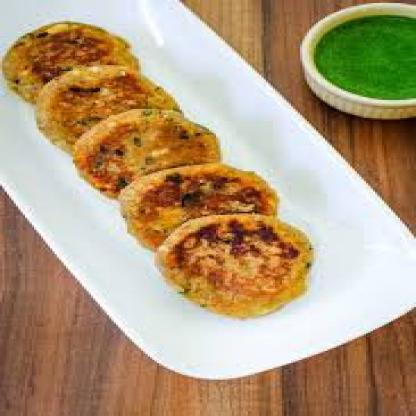

In [21]:
image = Image.open(image_path)

print("Image size:", image.size)

display(image)


In [22]:
print("========== GROUND TRUTH ==========")

with open(label_path, "r") as f:
    labels = [line.strip() for line in f if line.strip()]

for line in labels:

    values = line.split()

    class_id = int(values[0])

    print(model.names[class_id])

========== GROUND TRUTH ==========
aloo tikki
aloo tikki
aloo tikki
aloo tikki
aloo tikki


In [25]:
print("========== YOLO PREDICTIONS ==========")

results = model.predict(
    source=str(image_path),
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

total_detections = 0

for result in results:

    if result.boxes is None or len(result.boxes) == 0:
        print("No detections")
        continue

    for box in result.boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        food_name = model.names[class_id]

        total_detections += 1

        print(
            f"{total_detections}. "
            f"{food_name} | "
            f"Confidence: {confidence:.2%}"
        )

print("\nTotal detected objects:", total_detections)
print("Ground-truth objects: 5")

========== YOLO PREDICTIONS ==========
1. aloo tikki | Confidence: 35.08%
2. jalebi | Confidence: 29.57%

Total detected objects: 2
Ground-truth objects: 5


Image:


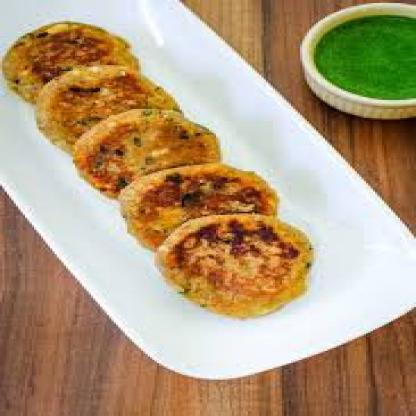


Ground-truth labels:
['16 0.5721153846153846 0.6418269230769231 0.36899038461538464 0.24759615384615385', '16 0.48197115384615385 0.4987980769230769 0.3641826923076923 0.20192307692307693', '16 0.35697115384615385 0.3713942307692308 0.3545673076923077 0.21754807692307693', '16 0.26322115384615385 0.2644230769230769 0.3485576923076923 0.21153846153846154', '16 0.17908653846153846 0.14783653846153846 0.31850961538461536 0.18870192307692307']


In [26]:
print("Image:")
display(Image.open(image_path))

print("\nGround-truth labels:")
print(labels)

YOLO prediction:


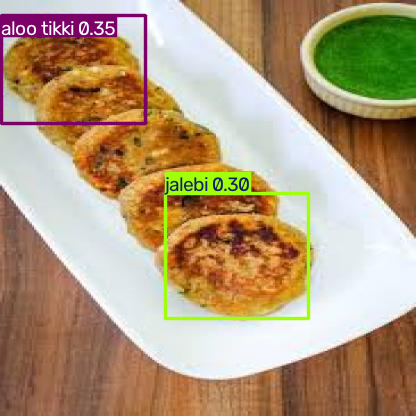

In [27]:
result_image = results[0].plot()

print("YOLO prediction:")
display(Image.fromarray(result_image[..., ::-1]))